# Data

Enlace a dataset completo (disponible para miembros del a UVG)

https://uvggt-my.sharepoint.com/:f:/r/personal/mar22398_uvg_edu_gt/Documents/dataset_proyecto_vision?csf=1&web=1&e=9ctzTG


In [1]:
from pathlib import Path
from collections import defaultdict
import re

# Root dataset directory
DATA_DIR = Path("data")

# Match:
# image-123.jpg
# image-123-labeled.png
pattern = re.compile(r"image-\d+(-labeled)?\.[a-zA-Z0-9]+")

summary = {}

for category_dir in DATA_DIR.iterdir():
    if category_dir.is_dir():
        counts = defaultdict(int)

        for file in category_dir.iterdir():
            if file.is_file() and pattern.fullmatch(file.name):
                
                if "-labeled" in file.stem:
                    counts["labeled"] += 1
                else:
                    counts["unlabeled"] += 1

                counts["total"] += 1

        summary[category_dir.name] = counts

# Print results
print("Dataset summary:\n")

grand_total = 0

for category, counts in summary.items():
    print(f"{category}")
    print(f"  Total:      {counts['total']}")
    print(f"  Unlabeled:  {counts['unlabeled']}")
    print(f"  Labeled:    {counts['labeled']}")
    print()

    grand_total += counts["total"]

print(f"Grand total files: {grand_total}")

Dataset summary:

bottles
  Total:      325
  Unlabeled:  164
  Labeled:    161

tshirts
  Total:      172
  Unlabeled:  86
  Labeled:    86

Grand total files: 497


Se cuenta con 161 imagenes de botellas unicas y 86 de camisas unicas. Cada imagen tiene su version original (la que servira como x del modelo) mientras que las imagenes labeled poseen la ubicacion del logo como imagen.

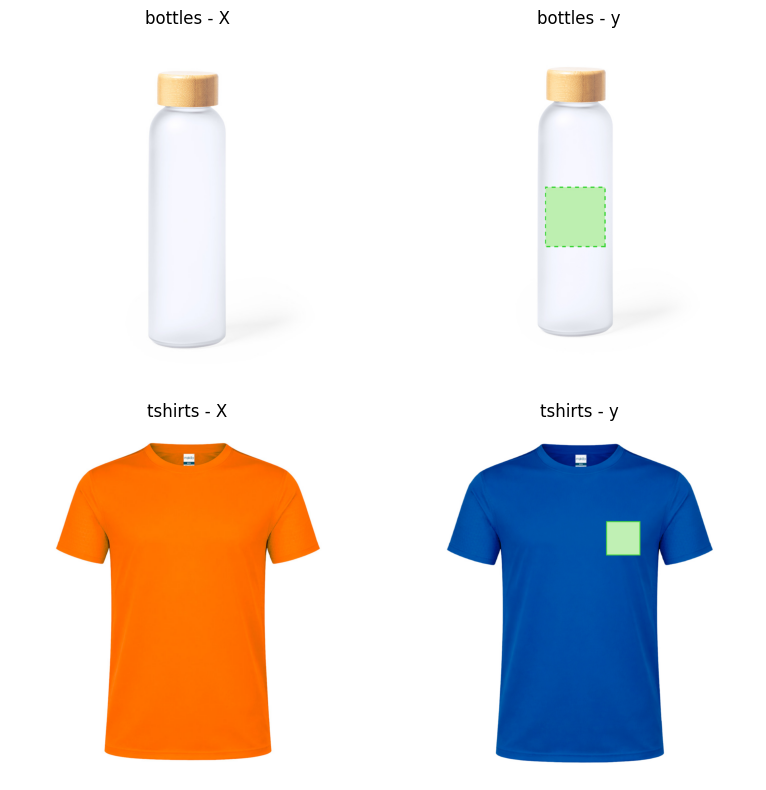

In [4]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
categories = ["bottles", "tshirts"]

samples = []

for category in categories:
    category_dir = DATA_DIR / category

    # Only original images
    images = [
        f for f in category_dir.iterdir()
        if f.is_file() and "-labeled" not in f.stem
    ]

    # Pick random image
    img_path = random.choice(images)

    # Corresponding label path
    label_path = category_dir / f"{img_path.stem}-labeled{img_path.suffix}"

    samples.append((category, img_path, label_path))

# Plot: each row = category, columns = X and y
fig, axes = plt.subplots(len(samples), 2, figsize=(8, 8))

for row, (category, img_path, label_path) in enumerate(samples):

    x_img = Image.open(img_path)
    y_img = Image.open(label_path) if label_path.exists() else None

    # X
    axes[row, 0].imshow(x_img)
    axes[row, 0].set_title(f"{category} - X")
    axes[row, 0].axis("off")

    # y
    if y_img:
        axes[row, 1].imshow(y_img)
        axes[row, 1].set_title(f"{category} - y")
    else:
        axes[row, 1].text(0.5, 0.5, "No label found", ha="center", va="center")
        axes[row, 1].set_title(f"{category} - y")

    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

Como se menciono en el plan de proyecto, la imagen de label no nos importa actualmente que sea del mismo color que la imagen original, sino que tenga las mismas proporciones, pues el siguiente paso sera extraer la bounding-box en formato yolo.

Por tanto ahora tenemos
```
    X: imagen original
    y-pre: imagen con rectangulo
```

Y lo que se necesita para el modelo es:
```
    X: imagen original
    y-post: bounding box
```

Esto se obtendra utilizando filtros clasicos de vision por computadora y morfologia.
